# Spain vs Austria — Style-Adjusted Prediction Model

This notebook builds a pre-match prediction model for Spain vs Austria.

The model is intentionally our own. It does not use betting odds, external score predictions, or third-party win probabilities. It uses observed match logs, comparable-style evidence, tactical style profiles, model weights and a Monte Carlo simulation.

The key idea is simple: Spain is not evaluated only by its average performance, and Austria is not evaluated only by its average performance. The model adds a comparable-style factor:

- Spain against Austria-like opponents: compact, disruptive, transition-oriented or low-block teams.
- Austria against Spain-like opponents: high-possession, territorial-control and technically dominant teams.

All assumptions are visible in the CSV files and in the code below.

## 1. Project setup

In [1]:
# Import libraries
from pathlib import Path
import sys
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Arc, FancyArrowPatch
from matplotlib.lines import Line2D
from IPython.display import display

# Resolve project paths whether the notebook is run from the root folder or from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
REPORTS_DIR = PROJECT_ROOT / "reports"

OUTPUT_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

# Visual defaults
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titleweight"] = "bold"

SPAIN = "#C8102E"
AUSTRIA = "#1F2937"
GOLD = "#F59E0B"
GREEN = "#059669"
BLUE = "#2563EB"
GREY = "#6B7280"
LIGHT = "#F8FAFC"
GRID = "#E5E7EB"
TEXT = "#111827"

# Helper function to save charts consistently
def save_chart(filename):
    path = OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path.relative_to(PROJECT_ROOT)}")

## 2. Load input data

The CSV files separate observed match data, tactical style inputs and model configuration. This makes the model easier to audit and easier to improve later.

In [2]:
# Load datasets
spain_log = pd.read_csv(DATA_DIR / "spain_match_log.csv")
austria_log = pd.read_csv(DATA_DIR / "austria_match_log.csv")
comparables = pd.read_csv(DATA_DIR / "comparable_matches.csv")
styles = pd.read_csv(DATA_DIR / "team_style_profiles.csv")
weights = pd.read_csv(DATA_DIR / "model_weights.csv")
sources = pd.read_csv(DATA_DIR / "source_register.csv")

# Show raw inputs
display(spain_log)
display(austria_log)
display(comparables)
display(styles)

,match_id,date,team,opponent,competition,phase,team_goals,opponent_goals,team_xg,opponent_xg,...,team_sot,opponent_sot,team_possession,team_pass_accuracy,team_corners,team_high_recoveries,team_fouls,opponent_style_cluster,data_quality,source_note
0,ESP_CPV_2026,2026-06-15,Spain,Cape Verde,FIFA World Cup 2026,Group H,0,0,2.29,0.30,...,7,1,74,92,NaN,8,9,compact_low_block,observed_public_report,"ESPN reported Spain 27 shots, 7 on target and ..."
1,ESP_KSA_2026,2026-06-21,Spain,Saudi Arabia,FIFA World Cup 2026,Group H,4,0,2.85,0.04,...,8,1,72,91,6.0,10,8,low_block_counter,observed_public_report,ESPN reported Spain 2.85 xG and Saudi Arabia 0...
2,ESP_URU_2026,2026-06-26,Spain,Uruguay,FIFA World Cup 2026,Group H,1,0,0.86,0.20,...,1,1,64,90,4.0,6,12,compact_transition_elite,observed_public_report,The Analyst/ESPN reported Spain 0.86 xG from 6...
3,ESP_ITA_2024,2024-06-20,Spain,Italy,UEFA Euro 2024,Group stage,1,0,1.90,0.20,...,8,1,58,89,5.0,9,17,compact_high_intensity,research_input,Pre-World-Cup comparable included to capture S...
4,ESP_CRO_2024,2024-06-15,Spain,Croatia,UEFA Euro 2024,Group stage,3,0,2.00,2.10,...,5,5,47,86,5.0,7,14,direct_transition_elite,research_input,Pre-World-Cup comparable included to capture S...


,match_id,date,team,opponent,competition,phase,team_goals,opponent_goals,team_xg,opponent_xg,...,team_sot,opponent_sot,team_possession,team_pass_accuracy,team_corners,team_high_recoveries,team_fouls,opponent_style_cluster,data_quality,source_note
0,AUT_JOR_2026,2026-06-17,Austria,Jordan,FIFA World Cup 2026,Group J,3,1,NaN,NaN,...,2,4,56,86,5,10,13,mid_block_transition,observed_public_report,Guardian live report described Jordan 11 shots...
1,AUT_ARG_2026,2026-06-22,Austria,Argentina,FIFA World Cup 2026,Group J,0,2,0.5,2.65,...,2,7,39,82,3,7,16,elite_possession_attack,observed_public_report,ESPN reported Argentina 2.65 xG and Austria 0....
2,AUT_ALG_2026,2026-06-27,Austria,Algeria,FIFA World Cup 2026,Group J,3,3,NaN,1.67,...,3,5,35,78,4,8,15,direct_transition_press,observed_public_report,Algeria-Austria ended 3-3; ESPN/Sofascore-styl...
3,AUT_FRA_2024,2024-06-17,Austria,France,UEFA Euro 2024,Group stage,0,1,0.8,2.10,...,3,3,48,83,6,11,18,elite_possession_attack,research_input,Pre-World-Cup comparable included to measure A...
4,AUT_NED_2024,2024-06-25,Austria,Netherlands,UEFA Euro 2024,Group stage,3,2,1.3,1.70,...,5,2,47,81,5,12,16,possession_with_width,research_input,Pre-World-Cup comparable included to measure A...


,team,match_id,opponent,comparison_type,opponent_similarity_to_next_opponent,style_similarity_score,weight_in_model,reason
0,Spain,ESP_CPV_2026,Cape Verde,Spain_vs_Austria_like,0.82,0.86,1.00,"Low block, compact defending and underdog game..."
1,Spain,ESP_URU_2026,Uruguay,Spain_vs_Austria_like,0.74,0.78,0.85,Compact transition threat and physical defensi...
2,Spain,ESP_ITA_2024,Italy,Spain_vs_Austria_like,0.68,0.75,0.65,Elite compact opponent with intensity and defe...
3,Spain,ESP_CRO_2024,Croatia,Spain_vs_Austria_like,0.62,0.70,0.55,"Direct transition danger, useful for rest-defe..."
4,Austria,AUT_ARG_2026,Argentina,Austria_vs_Spain_like,0.88,0.91,1.00,Elite possession and attacking control opponen...
5,Austria,AUT_FRA_2024,France,Austria_vs_Spain_like,0.78,0.82,0.70,Elite territorial opponent with individual qua...
6,Austria,AUT_NED_2024,Netherlands,Austria_vs_Spain_like,0.70,0.76,0.60,"Possession with width, useful for Austria defe..."
7,Austria,AUT_ALG_2026,Algeria,Austria_vs_Spain_like,0.44,0.52,0.35,"Lower Spain similarity, but useful for Austria..."


,team,possession_control,patient_build_up,progressive_passing,wide_progression,chance_creation,shot_quality,defensive_security,rest_defence,counterpressing,pressing_intensity,direct_transitions,low_block_resilience,set_piece_threat,disruption_capacity
0,Spain,92,88,86,84,80,68,86,84,80,72,58,70,62,66
1,Austria,56,50,64,62,62,60,70,66,84,88,84,82,76,86


## 3. Data preparation

Some match-centre values are unavailable for every match. When xG is missing, the notebook creates an internal xG estimate from shots, shots on target and goals. That imputation is clearly marked and used only to avoid throwing away useful comparable matches.

In [3]:
# Convert model weights into a dictionary
model_weights = dict(zip(weights["parameter"], weights["value"]))
RECENT_WC_WEIGHT = float(model_weights["recent_world_cup_weight"])
PRE_WC_WEIGHT = float(model_weights["pre_world_cup_weight"])
COMPARABLE_LAYER_WEIGHT = float(model_weights["comparable_layer_weight"])
STYLE_LAYER_WEIGHT = float(model_weights["style_layer_weight"])
UNCERTAINTY_MULTIPLIER = float(model_weights["uncertainty_multiplier"])
N_SIMULATIONS = int(model_weights["monte_carlo_simulations"])
RANDOM_SEED = int(model_weights["random_seed"])

# Impute xG when not available
# This is not an external prediction: it is a transparent internal estimate from observed shot volume, SOT and goals.
def impute_team_xg(row):
    if pd.notna(row["team_xg"]):
        return float(row["team_xg"]), "observed"
    estimate = 0.06 * row["team_shots"] + 0.14 * row["team_sot"] + 0.10 * row["team_goals"]
    return max(0.10, float(estimate)), "imputed_from_shots_sot_goals"

def impute_opponent_xg(row):
    if pd.notna(row["opponent_xg"]):
        return float(row["opponent_xg"]), "observed"
    estimate = 0.06 * row["opponent_shots"] + 0.14 * row["opponent_sot"] + 0.10 * row["opponent_goals"]
    return max(0.10, float(estimate)), "imputed_from_shots_sot_goals"

def prepare_log(df):
    df = df.copy()
    team_xg_info = df.apply(impute_team_xg, axis=1, result_type="expand")
    opp_xg_info = df.apply(impute_opponent_xg, axis=1, result_type="expand")
    df["team_xg_model"] = team_xg_info[0]
    df["team_xg_type"] = team_xg_info[1]
    df["opponent_xg_model"] = opp_xg_info[0]
    df["opponent_xg_type"] = opp_xg_info[1]
    df["is_world_cup_2026"] = df["competition"].str.contains("World Cup 2026", case=False, na=False)
    df["time_weight"] = np.where(df["is_world_cup_2026"], RECENT_WC_WEIGHT, PRE_WC_WEIGHT)
    df["shot_quality_for"] = df["team_xg_model"] / df["team_shots"].replace(0, np.nan)
    df["shot_quality_against"] = df["opponent_xg_model"] / df["opponent_shots"].replace(0, np.nan)
    df["sot_rate_for"] = df["team_sot"] / df["team_shots"].replace(0, np.nan)
    df["sot_rate_against"] = df["opponent_sot"] / df["opponent_shots"].replace(0, np.nan)
    return df

spain = prepare_log(spain_log)
austria = prepare_log(austria_log)

# Review prepared logs
review_cols = [
    "team", "opponent", "team_goals", "opponent_goals", "team_xg_model", "team_xg_type",
    "opponent_xg_model", "opponent_xg_type", "team_shots", "opponent_shots", "opponent_style_cluster"
]
display(spain[review_cols])
display(austria[review_cols])

,team,opponent,team_goals,opponent_goals,team_xg_model,team_xg_type,opponent_xg_model,opponent_xg_type,team_shots,opponent_shots,opponent_style_cluster
0,Spain,Cape Verde,0,0,2.29,observed,0.30,observed,27,6,compact_low_block
1,Spain,Saudi Arabia,4,0,2.85,observed,0.04,observed,22,4,low_block_counter
2,Spain,Uruguay,1,0,0.86,observed,0.20,observed,6,5,compact_transition_elite
3,Spain,Italy,1,0,1.90,observed,0.20,observed,20,4,compact_high_intensity
4,Spain,Croatia,3,0,2.00,observed,2.10,observed,11,16,direct_transition_elite


,team,opponent,team_goals,opponent_goals,team_xg_model,team_xg_type,opponent_xg_model,opponent_xg_type,team_shots,opponent_shots,opponent_style_cluster
0,Austria,Jordan,3,1,1.18,imputed_from_shots_sot_goals,1.32,imputed_from_shots_sot_goals,10,11,mid_block_transition
1,Austria,Argentina,0,2,0.50,observed,2.65,observed,7,17,elite_possession_attack
2,Austria,Algeria,3,3,1.32,imputed_from_shots_sot_goals,1.67,observed,10,12,direct_transition_press
3,Austria,France,0,1,0.80,observed,2.10,observed,5,14,elite_possession_attack
4,Austria,Netherlands,3,2,1.30,observed,1.70,observed,9,11,possession_with_width


## 4. Baseline team profiles

The baseline layer looks at recent attacking production, defensive concession, shot volume, shot quality and control. Recent World Cup matches receive more weight than older comparable matches.

In [4]:
# Weighted average helper

def wavg(df, value_col, weight_col="time_weight"):
    values = df[value_col].astype(float)
    weights_ = df[weight_col].astype(float)
    mask = values.notna() & weights_.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights_[mask])

# Build a compact team profile from match logs

def build_baseline_profile(df):
    return pd.Series({
        "xg_for": wavg(df, "team_xg_model"),
        "xg_against": wavg(df, "opponent_xg_model"),
        "goals_for": wavg(df, "team_goals"),
        "goals_against": wavg(df, "opponent_goals"),
        "shots_for": wavg(df, "team_shots"),
        "shots_against": wavg(df, "opponent_shots"),
        "sot_for": wavg(df, "team_sot"),
        "sot_against": wavg(df, "opponent_sot"),
        "shot_quality_for": wavg(df, "shot_quality_for"),
        "shot_quality_against": wavg(df, "shot_quality_against"),
        "sot_rate_for": wavg(df, "sot_rate_for"),
        "sot_rate_against": wavg(df, "sot_rate_against"),
        "possession": wavg(df, "team_possession"),
        "pass_accuracy": wavg(df, "team_pass_accuracy"),
        "high_recoveries": wavg(df, "team_high_recoveries"),
        "fouls": wavg(df, "team_fouls")
    })

baseline = pd.DataFrame({
    "Spain": build_baseline_profile(spain),
    "Austria": build_baseline_profile(austria)
}).T.round(3)

display(baseline)

,xg_for,xg_against,goals_for,goals_against,shots_for,shots_against,sot_for,sot_against,shot_quality_for,shot_quality_against,sot_rate_for,sot_rate_against,possession,pass_accuracy,high_recoveries,fouls
Spain,1.987,0.436,1.755,0.000,17.585,6.321,5.642,1.528,0.124,0.048,0.307,0.226,65.377,90.075,8.00,11.208
Austria,1.013,1.885,1.868,1.868,8.472,13.113,2.774,4.585,0.119,0.142,0.345,0.345,44.434,82.000,9.17,15.283


## 5. Comparable-style layer

This is the central correction requested for the project. The model explicitly asks:

- How has Spain performed against opponents with Austria-like traits?
- How has Austria performed against opponents with Spain-like traits?

This is not a simple team average. Comparable matches are weighted by tactical similarity.

In [5]:
# Attach comparable metadata to match logs
all_logs = pd.concat([spain, austria], ignore_index=True)
comp_logs = comparables.merge(all_logs, on=["team", "match_id", "opponent"], how="left")

# Comparable weight combines manually defined model weight and style similarity
comp_logs["combined_comparable_weight"] = comp_logs["weight_in_model"] * comp_logs["style_similarity_score"]

# Compute comparable profiles for each comparison type

def comparable_profile(team_name, comparison_type):
    df = comp_logs[(comp_logs["team"] == team_name) & (comp_logs["comparison_type"] == comparison_type)].copy()
    return pd.Series({
        "comp_xg_for": np.average(df["team_xg_model"], weights=df["combined_comparable_weight"]),
        "comp_xg_against": np.average(df["opponent_xg_model"], weights=df["combined_comparable_weight"]),
        "comp_shots_for": np.average(df["team_shots"], weights=df["combined_comparable_weight"]),
        "comp_shots_against": np.average(df["opponent_shots"], weights=df["combined_comparable_weight"]),
        "comp_sot_for": np.average(df["team_sot"], weights=df["combined_comparable_weight"]),
        "comp_sot_against": np.average(df["opponent_sot"], weights=df["combined_comparable_weight"]),
        "comp_possession": np.average(df["team_possession"], weights=df["combined_comparable_weight"]),
        "average_similarity": np.average(df["style_similarity_score"], weights=df["weight_in_model"]),
        "matches_used": len(df)
    })

spain_comp = comparable_profile("Spain", "Spain_vs_Austria_like")
austria_comp = comparable_profile("Austria", "Austria_vs_Spain_like")

comparable_summary = pd.DataFrame({
    "Spain vs Austria-like opponents": spain_comp,
    "Austria vs Spain-like opponents": austria_comp
}).T.round(3)

display(comp_logs[["team", "opponent", "comparison_type", "style_similarity_score", "combined_comparable_weight", "team_xg_model", "opponent_xg_model", "team_shots", "opponent_shots"]])
display(comparable_summary)

,team,opponent,comparison_type,style_similarity_score,combined_comparable_weight,team_xg_model,opponent_xg_model,team_shots,opponent_shots
0,Spain,Cape Verde,Spain_vs_Austria_like,0.86,0.8600,2.29,0.30,27,6
1,Spain,Uruguay,Spain_vs_Austria_like,0.78,0.6630,0.86,0.20,6,5
2,Spain,Italy,Spain_vs_Austria_like,0.75,0.4875,1.90,0.20,20,4
3,Spain,Croatia,Spain_vs_Austria_like,0.70,0.3850,2.00,2.10,11,16
4,Austria,Argentina,Austria_vs_Spain_like,0.91,0.9100,0.50,2.65,7,17
5,Austria,France,Austria_vs_Spain_like,0.82,0.5740,0.80,2.10,5,14
6,Austria,Netherlands,Austria_vs_Spain_like,0.76,0.4560,1.30,1.70,9,11
7,Austria,Algeria,Austria_vs_Spain_like,0.52,0.1820,1.32,1.67,10,12


,comp_xg_for,comp_xg_against,comp_shots_for,comp_shots_against,comp_sot_for,comp_sot_against,comp_possession,average_similarity,matches_used
Spain vs Austria-like opponents,1.768,0.541,17.192,6.923,5.221,1.643,63.637,0.785,4.0
Austria vs Spain-like opponents,0.823,2.213,7.146,14.470,3.001,4.672,42.811,0.801,4.0


## 6. Tactical style profiles

The style profile does not try to pretend that tactical behaviour is exact event data. It is a structured scouting proxy used to adjust the model according to the matchup.

In [6]:
# Prepare tactical profile table
style_indexed = styles.set_index("team")
spain_style = style_indexed.loc["Spain"]
austria_style = style_indexed.loc["Austria"]

# Create tactical macro indexes

def tactical_indexes(style):
    return pd.Series({
        "control_index": np.mean([style["possession_control"], style["patient_build_up"], style["progressive_passing"], style["wide_progression"]]),
        "chance_creation_index": np.mean([style["chance_creation"], style["shot_quality"], style["progressive_passing"], style["wide_progression"]]),
        "rest_defence_index": np.mean([style["defensive_security"], style["rest_defence"], style["counterpressing"]]),
        "disruption_index": np.mean([style["pressing_intensity"], style["counterpressing"], style["disruption_capacity"]]),
        "transition_index": np.mean([style["direct_transitions"], style["pressing_intensity"], style["set_piece_threat"]]),
        "low_block_index": np.mean([style["low_block_resilience"], style["defensive_security"], style["set_piece_threat"]])
    })

style_indexes = pd.DataFrame({
    "Spain": tactical_indexes(spain_style),
    "Austria": tactical_indexes(austria_style)
}).T.round(2)

display(style_indexes)

,control_index,chance_creation_index,rest_defence_index,disruption_index,transition_index,low_block_index
Spain,87.5,79.5,83.33,72.67,64.00,72.67
Austria,58.0,62.0,73.33,86.00,82.67,76.00


## 7. Style-adjusted expected goals model

The model-generated xG is built from three layers:

1. Team baseline performance.
2. Comparable-style performance.
3. Tactical matchup adjustment.

No external prediction source is used.

In [7]:
# Baseline and comparable inputs
spain_base_xg_for = baseline.loc["Spain", "xg_for"]
spain_base_xg_against = baseline.loc["Spain", "xg_against"]
austria_base_xg_for = baseline.loc["Austria", "xg_for"]
austria_base_xg_against = baseline.loc["Austria", "xg_against"]

spain_comp_xg_for = spain_comp["comp_xg_for"]
spain_comp_xg_against = spain_comp["comp_xg_against"]
austria_comp_xg_for = austria_comp["comp_xg_for"]
austria_comp_xg_against = austria_comp["comp_xg_against"]

# Tactical adjustments are centred around zero and capped to avoid overfitting subjective style inputs.
spain_attack_style_edge = (
    style_indexes.loc["Spain", "chance_creation_index"]
    - style_indexes.loc["Austria", "low_block_index"]
) / 100

spain_control_edge = (
    style_indexes.loc["Spain", "control_index"]
    - style_indexes.loc["Austria", "disruption_index"]
) / 100

austria_transition_edge = (
    style_indexes.loc["Austria", "transition_index"]
    - style_indexes.loc["Spain", "rest_defence_index"]
) / 100

austria_disruption_edge = (
    style_indexes.loc["Austria", "disruption_index"]
    - style_indexes.loc["Spain", "control_index"]
) / 100

# Convert style edges into xG multipliers.
spain_style_multiplier = 1 + np.clip(STYLE_LAYER_WEIGHT * (0.65 * spain_attack_style_edge + 0.35 * spain_control_edge), -0.18, 0.18)
austria_style_multiplier = 1 + np.clip(STYLE_LAYER_WEIGHT * (0.70 * austria_transition_edge + 0.30 * austria_disruption_edge), -0.18, 0.18)

# Spain xG combines its own attack, its comparable performance, and Austria concessions vs Spain-like opponents.
spain_raw_lambda = (
    0.40 * spain_base_xg_for
    + 0.35 * spain_comp_xg_for
    + 0.25 * austria_comp_xg_against
)

# Austria xG combines its own attack, its comparable performance, and Spain concessions vs Austria-like opponents.
austria_raw_lambda = (
    0.40 * austria_base_xg_for
    + 0.30 * austria_comp_xg_for
    + 0.30 * spain_comp_xg_against
)

# Knockout caution slightly compresses both attacks.
knockout_caution = 0.94
spain_lambda = float(np.clip(spain_raw_lambda * spain_style_multiplier * knockout_caution, 0.25, 3.20))
austria_lambda = float(np.clip(austria_raw_lambda * austria_style_multiplier * knockout_caution, 0.15, 2.20))

xg_decomposition = pd.DataFrame([
    ["Spain baseline xG for", spain_base_xg_for, "Observed recent attacking production"],
    ["Spain xG vs Austria-like opponents", spain_comp_xg_for, "Comparable-style attacking evidence"],
    ["Austria xG conceded vs Spain-like opponents", austria_comp_xg_against, "Opponent defensive concession under similar style pressure"],
    ["Spain tactical multiplier", spain_style_multiplier, "Style adjustment from control, chance creation and Austria resistance"],
    ["Spain final model xG", spain_lambda, "Model-generated expected goals"],
    ["Austria baseline xG for", austria_base_xg_for, "Observed recent attacking production"],
    ["Austria xG vs Spain-like opponents", austria_comp_xg_for, "Comparable-style attacking evidence"],
    ["Spain xG conceded vs Austria-like opponents", spain_comp_xg_against, "Opponent defensive concession under similar threat"],
    ["Austria tactical multiplier", austria_style_multiplier, "Style adjustment from transition/disruption vs Spain rest-defence"],
    ["Austria final model xG", austria_lambda, "Model-generated expected goals"],
], columns=["component", "value", "interpretation"])

display(xg_decomposition.round(3))

,component,value,interpretation
0,Spain baseline xG for,1.987,Observed recent attacking production
1,Spain xG vs Austria-like opponents,1.768,Comparable-style attacking evidence
2,Austria xG conceded vs Spain-like opponents,2.213,Opponent defensive concession under similar st...
3,Spain tactical multiplier,1.010,"Style adjustment from control, chance creation..."
4,Spain final model xG,1.867,Model-generated expected goals
5,Austria baseline xG for,1.013,Observed recent attacking production
6,Austria xG vs Spain-like opponents,0.823,Comparable-style attacking evidence
7,Spain xG conceded vs Austria-like opponents,0.541,Opponent defensive concession under similar th...
8,Austria tactical multiplier,0.997,Style adjustment from transition/disruption vs...
9,Austria final model xG,0.763,Model-generated expected goals


## 8. Visual: style-adjusted xG decomposition

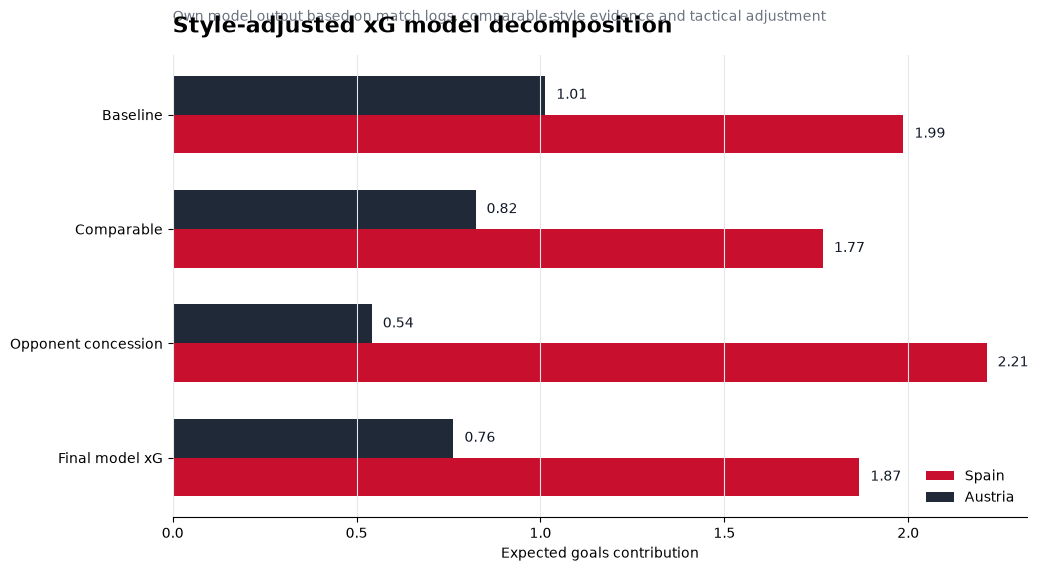

Saved: outputs\01_style_adjusted_xg_decomposition.png


In [8]:
# Plot model-generated xG decomposition
plot_df = pd.DataFrame({
    "component": ["Baseline", "Comparable", "Opponent concession", "Final model xG"],
    "Spain": [spain_base_xg_for, spain_comp_xg_for, austria_comp_xg_against, spain_lambda],
    "Austria": [austria_base_xg_for, austria_comp_xg_for, spain_comp_xg_against, austria_lambda]
})

fig, ax = plt.subplots(figsize=(10.5, 5.8))
y = np.arange(len(plot_df))
height = 0.34

ax.barh(y + height / 2, plot_df["Spain"], height=height, color=SPAIN, label="Spain")
ax.barh(y - height / 2, plot_df["Austria"], height=height, color=AUSTRIA, label="Austria")

for i, row in plot_df.iterrows():
    ax.text(row["Spain"] + 0.03, i + height / 2, f"{row['Spain']:.2f}", va="center", color=TEXT)
    ax.text(row["Austria"] + 0.03, i - height / 2, f"{row['Austria']:.2f}", va="center", color=TEXT)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["component"])
ax.invert_yaxis()
ax.set_xlabel("Expected goals contribution")
ax.set_title("Style-adjusted xG model decomposition", loc="left", fontsize=16, pad=16)
ax.text(0, -0.82, "Own model output based on match logs, comparable-style evidence and tactical adjustment", fontsize=10, color=GREY)
ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.legend(frameon=False, loc="lower right")

save_chart("01_style_adjusted_xg_decomposition.png")

## 9. Monte Carlo simulation

The final xG values are used as Poisson scoring rates. This gives a probability distribution of match outcomes and likely scorelines.

In [9]:
# Simulate match outcomes
rng = np.random.default_rng(RANDOM_SEED)
sim = pd.DataFrame({
    "spain_goals": rng.poisson(spain_lambda, N_SIMULATIONS),
    "austria_goals": rng.poisson(austria_lambda, N_SIMULATIONS)
})

sim["outcome"] = np.select(
    [sim["spain_goals"] > sim["austria_goals"], sim["spain_goals"] == sim["austria_goals"]],
    ["Spain win", "Draw after 90"],
    default="Austria win"
)

outcome_probs = sim["outcome"].value_counts(normalize=True).reindex(["Spain win", "Draw after 90", "Austria win"]).fillna(0)
scorelines = sim.groupby(["spain_goals", "austria_goals"]).size().div(N_SIMULATIONS).reset_index(name="probability")
scorelines = scorelines.sort_values("probability", ascending=False)

summary = pd.Series({
    "Spain model xG": spain_lambda,
    "Austria model xG": austria_lambda,
    "Spain win probability": outcome_probs["Spain win"],
    "Draw after 90 probability": outcome_probs["Draw after 90"],
    "Austria win probability": outcome_probs["Austria win"],
    "Spain clean sheet probability": (sim["austria_goals"] == 0).mean(),
    "Over 2.5 goals probability": ((sim["spain_goals"] + sim["austria_goals"]) > 2.5).mean(),
    "Both teams score probability": ((sim["spain_goals"] > 0) & (sim["austria_goals"] > 0)).mean()
})

display(summary.round(3))
display(scorelines.head(10))

Spain model xG                   1.867
Austria model xG                 0.763
Spain win probability            0.635
Draw after 90 probability        0.217
Austria win probability          0.148
Spain clean sheet probability    0.466
Over 2.5 goals probability       0.489
Both teams score probability     0.450
dtype: float64

,spain_goals,austria_goals,probability
7,1,0,0.13314
14,2,0,0.12680
8,1,1,0.10208
15,2,1,0.09460
21,3,0,0.07728
0,0,0,0.07228
22,3,1,0.06080
1,0,1,0.05574
9,1,2,0.03962
28,4,0,0.03718


## 10. Visual: Monte Carlo outcome probabilities

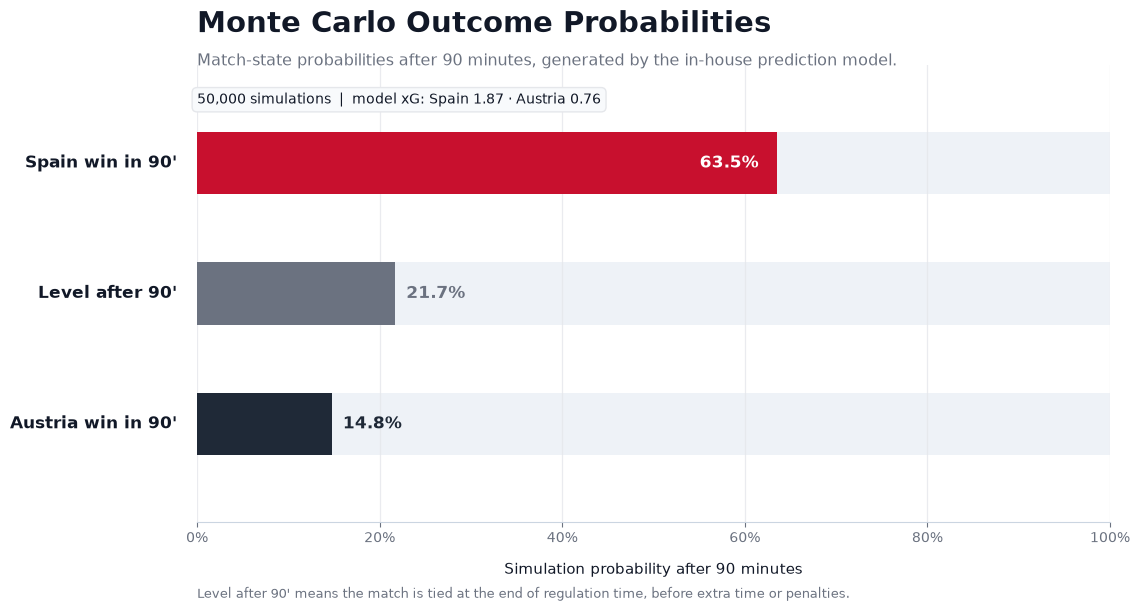

Saved: outputs\02_monte_carlo_outcome_probabilities.png


In [28]:
# Monte Carlo outcome probabilities

preferred_order = ["Spain win", "Draw after 90", "Austria win"]
plot_probs = outcome_probs.reindex(
    [label for label in preferred_order if label in outcome_probs.index]
)

# If labels do not match exactly, keep the original order
if plot_probs.empty or len(plot_probs) != len(outcome_probs):
    plot_probs = outcome_probs.copy()

raw_labels = plot_probs.index.tolist()
values = (plot_probs.values * 100).astype(float)

label_map = {
    "Spain win": "Spain win in 90'",
    "Draw": "Level after 90'",
    "Draw after 90": "Level after 90'",
    "Austria win": "Austria win in 90'"
}

labels = [label_map.get(label, label) for label in raw_labels]

color_map = {
    "Spain win in 90'": SPAIN,
    "Level after 90'": GREY,
    "Austria win in 90'": AUSTRIA
}

colors = [color_map.get(label, TEXT) for label in labels]

most_likely_idx = int(np.argmax(values))
most_likely_label = labels[most_likely_idx]
most_likely_value = values[most_likely_idx]

fig, ax = plt.subplots(figsize=(11.5, 6.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Plot area limits
ax.set_xlim(0, 100)
ax.set_ylim(-0.75, len(labels) - 0.25)

# Main title
ax.text(
    0, -0.95,
    "Monte Carlo Outcome Probabilities",
    fontsize=21,
    fontweight="bold",
    color=TEXT,
    ha="left",
    va="bottom",
    transform=ax.transData
)

# Subtitle
ax.text(
    0, -0.72,
    "Match-state probabilities after 90 minutes, generated by the in-house prediction model.",
    fontsize=11.2,
    color=GREY,
    ha="left",
    va="bottom",
    transform=ax.transData
)

# Model information box
ax.text(
    0, -0.43,
    f"{N_SIMULATIONS:,} simulations  |  model xG: Spain {spain_lambda:.2f} · Austria {austria_lambda:.2f}",
    fontsize=10.2,
    color=TEXT,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="#F8FAFC",
        edgecolor="#E5E7EB"
    ),
    transform=ax.transData
)

# Bars
y_positions = np.arange(len(labels))

for y, label, value, color in zip(y_positions, labels, values, colors):
    # Background track
    ax.barh(
        y,
        100,
        color="#EEF2F7",
        height=0.48,
        edgecolor="none",
        zorder=0
    )

    # Main bar
    ax.barh(
        y,
        value,
        color=color,
        height=0.48,
        edgecolor="none",
        zorder=2
    )

    # Category label
    ax.text(
        -2.2,
        y,
        label,
        ha="right",
        va="center",
        fontsize=12.2,
        fontweight="bold",
        color=TEXT
    )

    # Probability label
    if value >= 25:
        ax.text(
            value - 2.0,
            y,
            f"{value:.1f}%",
            ha="right",
            va="center",
            fontsize=12.5,
            fontweight="bold",
            color="white"
        )
    else:
        ax.text(
            value + 1.2,
            y,
            f"{value:.1f}%",
            ha="left",
            va="center",
            fontsize=12.5,
            fontweight="bold",
            color=color
        )




ax.text(
    0,
    len(labels) + 0.25,
    "Level after 90' means the match is tied at the end of regulation time, before extra time or penalties.",
    fontsize=9.5,
    color=GREY,
    ha="left",
    va="top"
)

# Axis styling
ax.set_yticks([])
ax.set_xticks(np.arange(0, 101, 20))
ax.set_xticklabels([f"{x}%" for x in np.arange(0, 101, 20)], fontsize=10.2, color=GREY)

ax.grid(axis="x", color=GRID, linewidth=0.9, alpha=0.8)
ax.set_axisbelow(True)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color("#CBD5E1")
ax.tick_params(axis="x", colors=GREY)

ax.set_xlabel(
    "Simulation probability after 90 minutes",
    fontsize=11,
    color=TEXT,
    labelpad=12
)

# Put Spain at the top
ax.invert_yaxis()

plt.tight_layout()
save_chart("02_monte_carlo_outcome_probabilities.png")

## 11. Visual: scoreline probability matrix

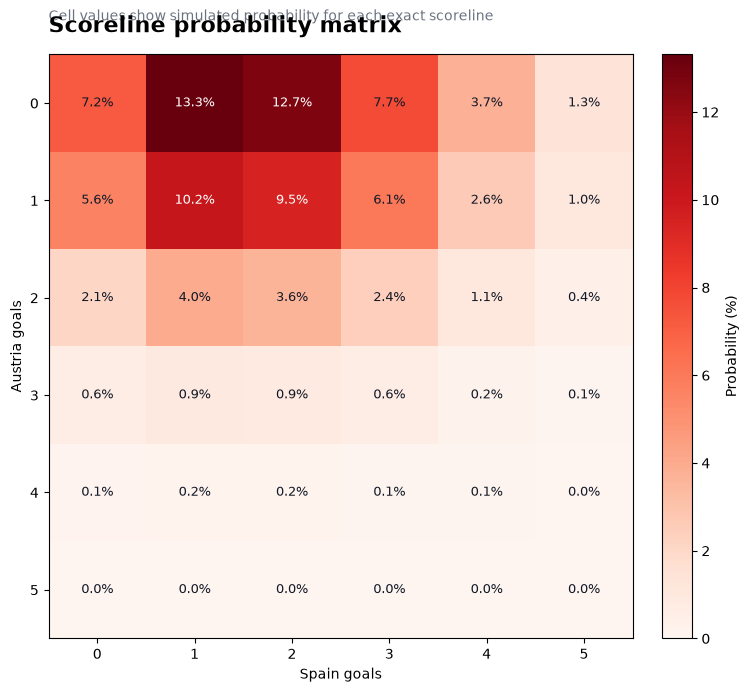

Saved: outputs\03_scoreline_probability_matrix.png


In [11]:
# Build scoreline probability matrix
max_goals = 5
matrix = np.zeros((max_goals + 1, max_goals + 1))
for _, row in scorelines.iterrows():
    sg = int(row["spain_goals"])
    ag = int(row["austria_goals"])
    if sg <= max_goals and ag <= max_goals:
        matrix[ag, sg] = row["probability"] * 100

fig, ax = plt.subplots(figsize=(8.2, 7))
im = ax.imshow(matrix, cmap="Reds")

for i in range(max_goals + 1):
    for j in range(max_goals + 1):
        value = matrix[i, j]
        ax.text(j, i, f"{value:.1f}%", ha="center", va="center", color=TEXT if value < matrix.max() * 0.65 else "white", fontsize=9)

ax.set_xticks(range(max_goals + 1))
ax.set_yticks(range(max_goals + 1))
ax.set_xlabel("Spain goals")
ax.set_ylabel("Austria goals")
ax.set_title("Scoreline probability matrix", loc="left", fontsize=16, pad=16)
ax.text(-0.5, -0.85, "Cell values show simulated probability for each exact scoreline", color=GREY, fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Probability (%)")

save_chart("03_scoreline_probability_matrix.png")

## 12. Derive projected match statistics from the model

The forecast card is now model-derived. The notebook does not manually define the expected statistics. It derives them from xG, shot quality, shot volume, possession profiles, comparable matches and style indicators.

In [12]:
# Create uncertainty ranges around a value

def make_range(value, uncertainty=UNCERTAINTY_MULTIPLIER, lower_floor=0):
    low = max(lower_floor, value * (1 - uncertainty))
    high = value * (1 + uncertainty)
    return low, high

# Derive shot volume from xG and shot quality
spain_shot_quality = np.clip(np.mean([baseline.loc["Spain", "shot_quality_for"], spain_comp["comp_xg_for"] / spain_comp["comp_shots_for"]]), 0.07, 0.18)
austria_shot_quality = np.clip(np.mean([baseline.loc["Austria", "shot_quality_for"], austria_comp["comp_xg_for"] / austria_comp["comp_shots_for"]]), 0.06, 0.20)

spain_expected_shots = spain_lambda / spain_shot_quality
austria_expected_shots = austria_lambda / austria_shot_quality

# Derive SOT from shot volume and observed SOT rate
spain_sot_rate = np.clip(np.mean([baseline.loc["Spain", "sot_rate_for"], spain_comp["comp_sot_for"] / spain_comp["comp_shots_for"]]), 0.25, 0.45)
austria_sot_rate = np.clip(np.mean([baseline.loc["Austria", "sot_rate_for"], austria_comp["comp_sot_for"] / austria_comp["comp_shots_for"]]), 0.22, 0.42)

spain_expected_sot = spain_expected_shots * spain_sot_rate
austria_expected_sot = austria_expected_shots * austria_sot_rate

# Derive possession from Spain control, Austria disruption and comparable possession logs
spain_possession_model = np.mean([
    baseline.loc["Spain", "possession"],
    spain_comp["comp_possession"],
    100 - austria_comp["comp_possession"],
    style_indexes.loc["Spain", "control_index"] - 0.35 * style_indexes.loc["Austria", "disruption_index"] + 24
])
spain_possession_model = float(np.clip(spain_possession_model, 55, 72))
austria_possession_model = 100 - spain_possession_model

# Derive other stats from possession, shots and style
spain_expected_passes = spain_possession_model * 9.8
austria_expected_passes = austria_possession_model * 9.2
spain_expected_corners = 0.28 * spain_expected_shots + 0.035 * spain_possession_model
austria_expected_corners = 0.25 * austria_expected_shots + 0.020 * austria_possession_model
spain_expected_high_recoveries = 0.45 * baseline.loc["Spain", "high_recoveries"] + 0.55 * (style_indexes.loc["Spain", "disruption_index"] / 10)
austria_expected_high_recoveries = 0.45 * baseline.loc["Austria", "high_recoveries"] + 0.55 * (style_indexes.loc["Austria", "disruption_index"] / 10)
spain_expected_fouls = baseline.loc["Spain", "fouls"] * 0.85 + style_indexes.loc["Austria", "transition_index"] / 18
austria_expected_fouls = baseline.loc["Austria", "fouls"] * 0.90 + style_indexes.loc["Austria", "disruption_index"] / 16

# Build forecast table
forecast_specs = [
    ("Possession (%)", spain_possession_model, austria_possession_model, 0.06, 0, "Comparable possession + style-control adjustment"),
    ("xG", spain_lambda, austria_lambda, 0.22, 0, "Final style-adjusted xG from our model"),
    ("Goals", sim["spain_goals"].mean(), sim["austria_goals"].mean(), 0.45, 0, "Monte Carlo goal distribution mean"),
    ("Shots", spain_expected_shots, austria_expected_shots, 0.20, 0, "xG divided by modelled shot quality"),
    ("Shots on target", spain_expected_sot, austria_expected_sot, 0.25, 0, "Shots multiplied by observed SOT-rate profile"),
    ("Corners", spain_expected_corners, austria_expected_corners, 0.22, 0, "Shot volume + territorial pressure"),
    ("Passes", spain_expected_passes, austria_expected_passes, 0.10, 0, "Possession model converted into pass-volume expectation"),
    ("High recoveries", spain_expected_high_recoveries, austria_expected_high_recoveries, 0.24, 0, "Observed recoveries + pressing/disruption style"),
    ("Fouls", spain_expected_fouls, austria_expected_fouls, 0.18, 0, "Observed fouls + game-disruption style")
]

forecast_rows = []
for metric, sp_value, au_value, uncert, floor, basis in forecast_specs:
    sp_low, sp_high = make_range(sp_value, uncert, floor)
    au_low, au_high = make_range(au_value, uncert, floor)
    forecast_rows.append({
        "metric": metric,
        "spain_low": sp_low,
        "spain_high": sp_high,
        "spain_mid": sp_value,
        "austria_low": au_low,
        "austria_high": au_high,
        "austria_mid": au_value,
        "basis": basis
    })

projected_stats = pd.DataFrame(forecast_rows)
projected_stats.to_csv(OUTPUT_DIR / "model_derived_projected_stats.csv", index=False)

display(projected_stats.round(2))

,metric,spain_low,spain_high,spain_mid,austria_low,austria_high,austria_mid,basis
0,Possession (%),62.89,70.91,66.90,31.11,35.09,33.10,Comparable possession + style-control adjustment
1,xG,1.46,2.28,1.87,0.60,0.93,0.76,Final style-adjusted xG from our model
2,Goals,1.03,2.71,1.87,0.42,1.11,0.77,Monte Carlo goal distribution mean
3,Shots,13.17,19.75,16.46,5.21,7.82,6.52,xG divided by modelled shot quality
4,Shots on target,3.77,6.28,5.03,1.87,3.12,2.49,Shots multiplied by observed SOT-rate profile
5,Corners,5.42,8.48,6.95,1.79,2.80,2.29,Shot volume + territorial pressure
6,Passes,590.07,721.19,655.63,274.06,334.96,304.51,Possession model converted into pass-volume ex...
7,High recoveries,5.77,9.42,7.60,6.73,10.98,8.86,Observed recoveries + pressing/disruption style
8,Fouls,11.58,16.66,14.12,15.69,22.57,19.13,Observed fouls + game-disruption style


## 13. Visual: model-derived projected match statistics

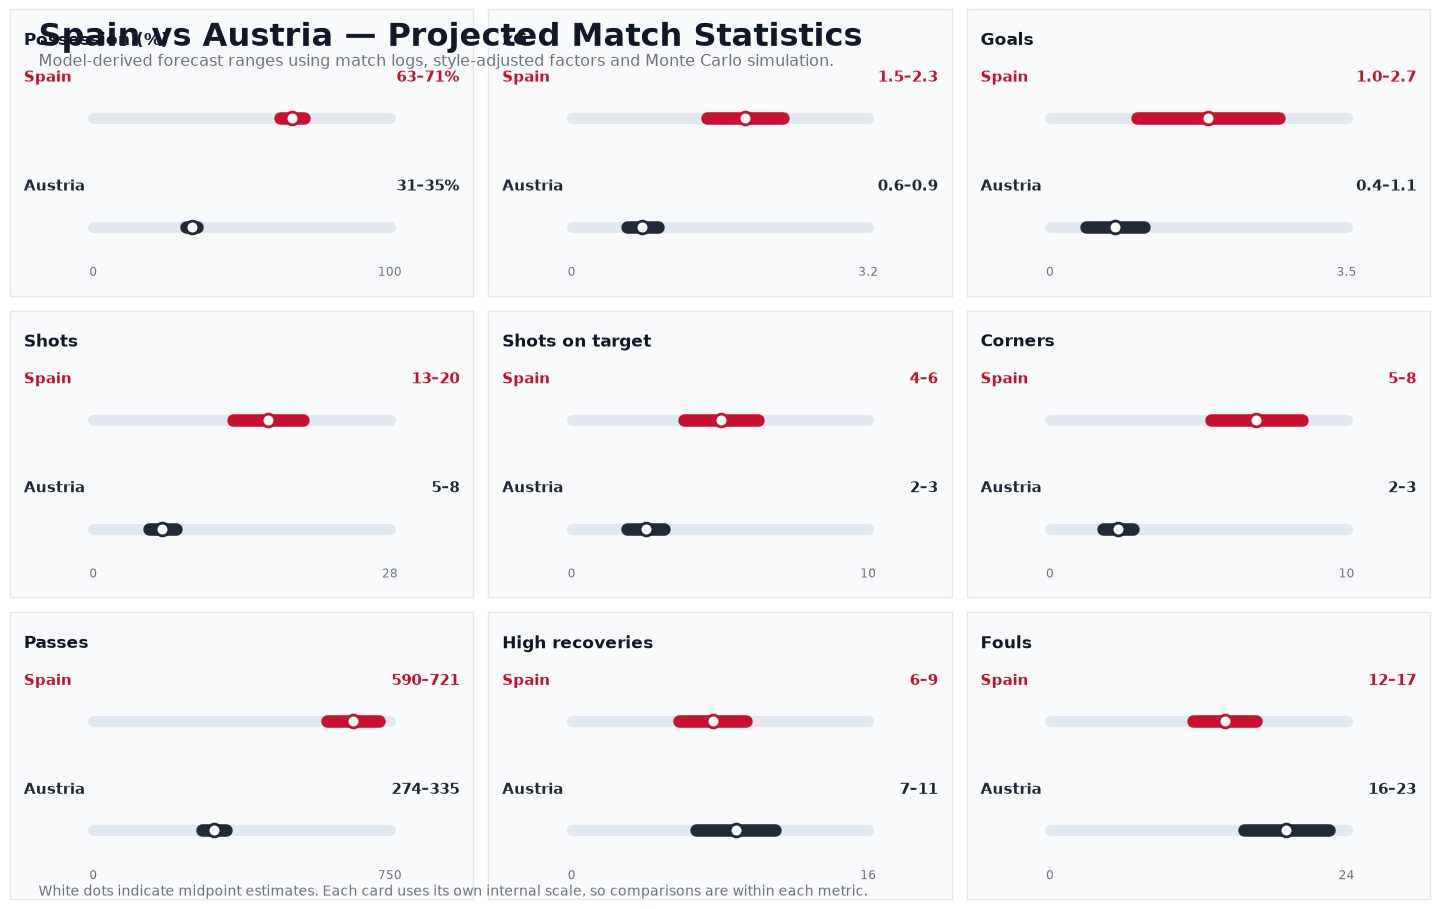

Saved: outputs\04_projected_match_stats_forecast_card.png


In [21]:
# Forecast card with model-derived ranges
plot_metrics = projected_stats.copy()

metric_scales = {
    "Possession (%)": 100,
    "xG": 3.2,
    "Goals": 3.5,
    "Shots": 28,
    "Shots on target": 10,
    "Corners": 10,
    "Passes": 750,
    "High recoveries": 16,
    "Fouls committed": 24,
    "Fouls": 24
}

def format_range(metric, low, high):
    integer_metrics = {
        "Shots", "Shots on target", "Corners",
        "Passes", "High recoveries", "Fouls committed", "Fouls"
    }
    
    if metric == "Possession (%)":
        return f"{low:.0f}–{high:.0f}%"
    elif metric in integer_metrics:
        return f"{low:.0f}–{high:.0f}"
    else:
        return f"{low:.1f}–{high:.1f}"

n_metrics = len(plot_metrics)
ncols = 3
nrows = (n_metrics + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14.5, 9.2))
axes = axes.flatten()
fig.patch.set_facecolor("white")

for ax in axes:
    ax.set_facecolor("#F8FAFC")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#E5E7EB")
        spine.set_linewidth(1.0)
    ax.set_xticks([])
    ax.set_yticks([])

fig.text(
    0.03, 0.97,
    "Spain vs Austria — Projected Match Statistics",
    fontsize=23, fontweight="bold", color=TEXT, ha="left", va="top"
)

fig.text(
    0.03, 0.935,
    "Model-derived forecast ranges using match logs, style-adjusted factors and Monte Carlo simulation.",
    fontsize=11.5, color=GREY, ha="left", va="top"
)

for i, (_, row) in enumerate(plot_metrics.iterrows()):
    ax = axes[i]
    
    metric = row["metric"]
    scale = metric_scales.get(
        metric,
        max(row["spain_high"], row["austria_high"]) * 1.15
    )
    
    sp_low, sp_high, sp_mid = row["spain_low"], row["spain_high"], row["spain_mid"]
    au_low, au_high, au_mid = row["austria_low"], row["austria_high"], row["austria_mid"]
    
    ax.set_xlim(0, scale)
    ax.set_ylim(0, 1)
    
    # Title of each mini-card
    ax.text(
        0.03 * scale, 0.92, metric,
        fontsize=12, fontweight="bold", color=TEXT,
        ha="left", va="top"
    )
    
    # Spain / Austria labels
    ax.text(
        0.03 * scale, 0.76, "Spain",
        fontsize=10.5, fontweight="bold", color=SPAIN,
        ha="left", va="center"
    )
    ax.text(
        0.97 * scale, 0.76, format_range(metric, sp_low, sp_high),
        fontsize=10.5, fontweight="bold", color=SPAIN,
        ha="right", va="center"
    )
    
    ax.text(
        0.03 * scale, 0.38, "Austria",
        fontsize=10.5, fontweight="bold", color=AUSTRIA,
        ha="left", va="center"
    )
    ax.text(
        0.97 * scale, 0.38, format_range(metric, au_low, au_high),
        fontsize=10.5, fontweight="bold", color=AUSTRIA,
        ha="right", va="center"
    )
    
    # Background tracks
    ax.plot([0.18 * scale, 0.82 * scale], [0.62, 0.62], color="#E2E8F0", lw=8, solid_capstyle="round")
    ax.plot([0.18 * scale, 0.82 * scale], [0.24, 0.24], color="#E2E8F0", lw=8, solid_capstyle="round")
    
    # Real ranges mapped into the track
    track_left = 0.18 * scale
    track_right = 0.82 * scale
    track_width = track_right - track_left
    
    def map_to_track(value):
        return track_left + (value / scale) * track_width
    
    # Spain bar
    ax.plot(
        [map_to_track(sp_low), map_to_track(sp_high)],
        [0.62, 0.62],
        color=SPAIN, lw=9, solid_capstyle="round"
    )
    ax.scatter(
        [map_to_track(sp_mid)], [0.62],
        s=85, color="white", edgecolor=SPAIN, linewidth=2, zorder=3
    )
    
    # Austria bar
    ax.plot(
        [map_to_track(au_low), map_to_track(au_high)],
        [0.24, 0.24],
        color=AUSTRIA, lw=9, solid_capstyle="round"
    )
    ax.scatter(
        [map_to_track(au_mid)], [0.24],
        s=85, color="white", edgecolor=AUSTRIA, linewidth=2, zorder=3
    )
    
    # Small min/max scale text
    ax.text(track_left, 0.08, "0", fontsize=8.5, color=GREY, ha="center", va="center")
    if metric == "Possession (%)":
        max_label = "100"
    else:
        max_label = f"{scale:.0f}" if scale >= 10 else f"{scale:.1f}"
    ax.text(track_right, 0.08, max_label, fontsize=8.5, color=GREY, ha="center", va="center")

# Hide empty cards
for j in range(n_metrics, len(axes)):
    axes[j].axis("off")

fig.text(
    0.03, 0.02,
    "White dots indicate midpoint estimates. Each card uses its own internal scale, so comparisons are within each metric.",
    fontsize=10, color=GREY, ha="left"
)

plt.tight_layout(rect=[0.02, 0.05, 0.98, 0.90])
save_chart("04_projected_match_stats_forecast_card.png")

## 14. Visual: tactical style radar

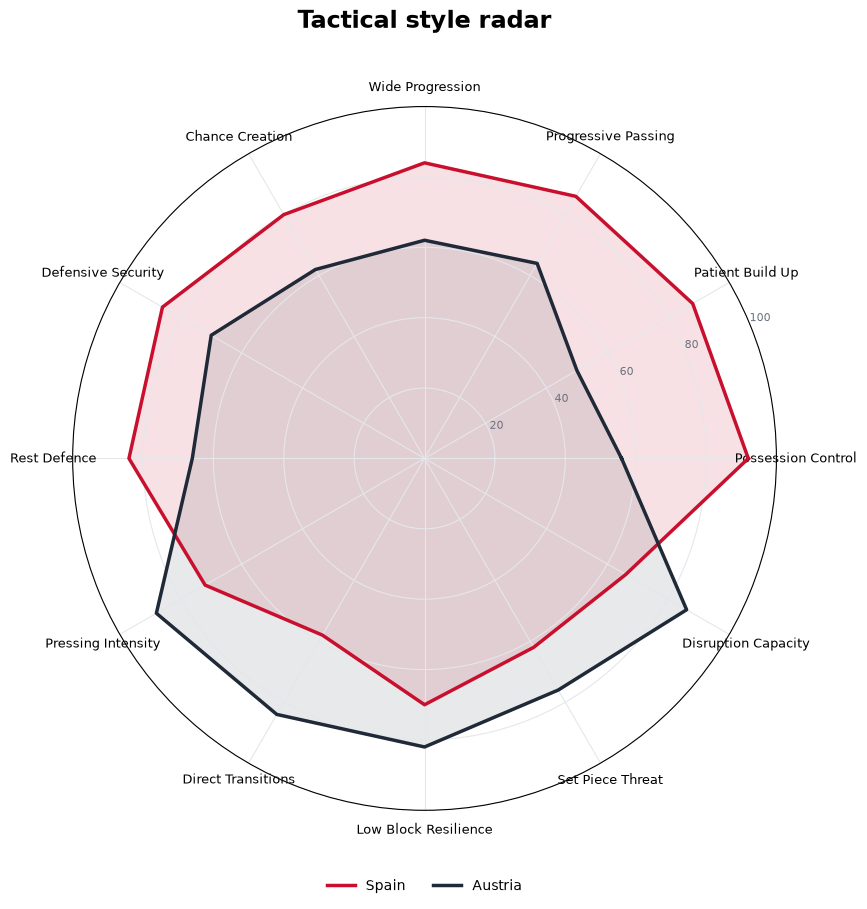

Saved: outputs\05_tactical_style_radar.png


In [14]:
# Radar chart for tactical profiles
radar_metrics = [
    "possession_control", "patient_build_up", "progressive_passing", "wide_progression",
    "chance_creation", "defensive_security", "rest_defence", "pressing_intensity",
    "direct_transitions", "low_block_resilience", "set_piece_threat", "disruption_capacity"
]

labels = [m.replace("_", " ").title() for m in radar_metrics]
angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]
spain_values = spain_style[radar_metrics].tolist() + spain_style[radar_metrics].tolist()[:1]
austria_values = austria_style[radar_metrics].tolist() + austria_style[radar_metrics].tolist()[:1]

fig = plt.figure(figsize=(9.2, 9.2))
ax = plt.subplot(111, polar=True)

ax.plot(angles, spain_values, color=SPAIN, lw=2.5, label="Spain")
ax.fill(angles, spain_values, color=SPAIN, alpha=0.12)
ax.plot(angles, austria_values, color=AUSTRIA, lw=2.5, label="Austria")
ax.fill(angles, austria_values, color=AUSTRIA, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(["20", "40", "60", "80", "100"], fontsize=8, color=GREY)
ax.set_ylim(0, 100)
ax.grid(color=GRID)
ax.set_title("Tactical style radar", y=1.10, fontsize=17, fontweight="bold")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)

save_chart("05_tactical_style_radar.png")

## 15. Visual: composite tactical indexes

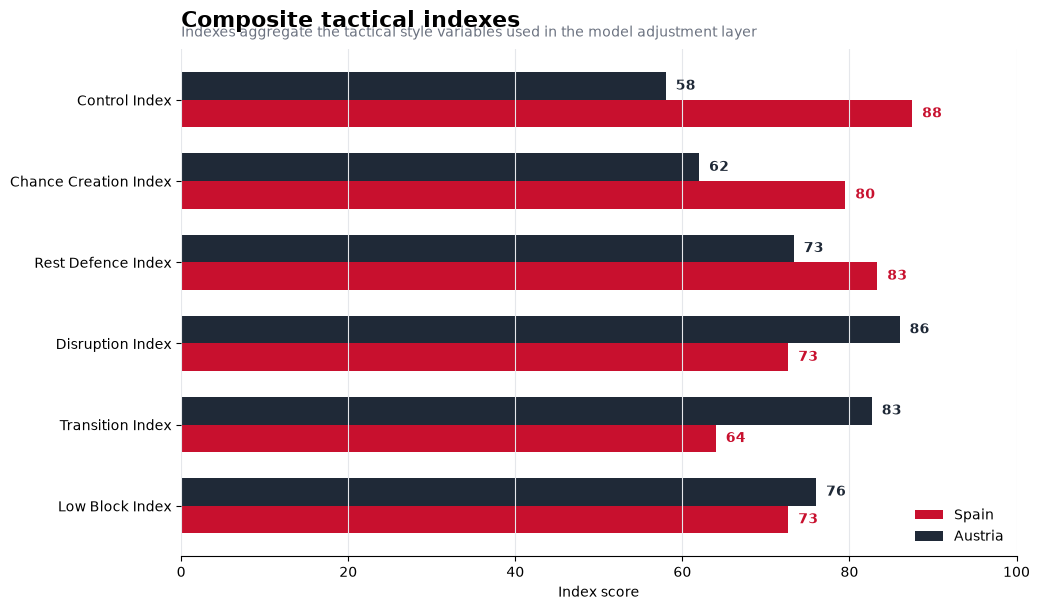

Saved: outputs\06_composite_tactical_indexes.png


In [15]:
# Composite tactical indexes
index_plot = style_indexes.T.reset_index().rename(columns={"index": "metric"})
index_plot["metric_label"] = index_plot["metric"].str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(10.5, 6.2))
y = np.arange(len(index_plot))
bar_h = 0.34

ax.barh(y + bar_h / 2, index_plot["Spain"], height=bar_h, color=SPAIN, label="Spain")
ax.barh(y - bar_h / 2, index_plot["Austria"], height=bar_h, color=AUSTRIA, label="Austria")

for i, row in index_plot.iterrows():
    ax.text(row["Spain"] + 1.2, i + bar_h / 2, f"{row['Spain']:.0f}", va="center", color=SPAIN, fontweight="bold")
    ax.text(row["Austria"] + 1.2, i - bar_h / 2, f"{row['Austria']:.0f}", va="center", color=AUSTRIA, fontweight="bold")

ax.set_yticks(y)
ax.set_yticklabels(index_plot["metric_label"])
ax.set_xlim(0, 100)
ax.invert_yaxis()
ax.set_xlabel("Index score")
ax.set_title("Composite tactical indexes", loc="left", fontsize=16, pad=16)
ax.text(0, -0.78, "Indexes aggregate the tactical style variables used in the model adjustment layer", fontsize=10, color=GREY)
ax.grid(axis="x", color=GRID)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.legend(frameon=False, loc="lower right")

save_chart("06_composite_tactical_indexes.png")

## 16. Visual: matchup advantage heatmap

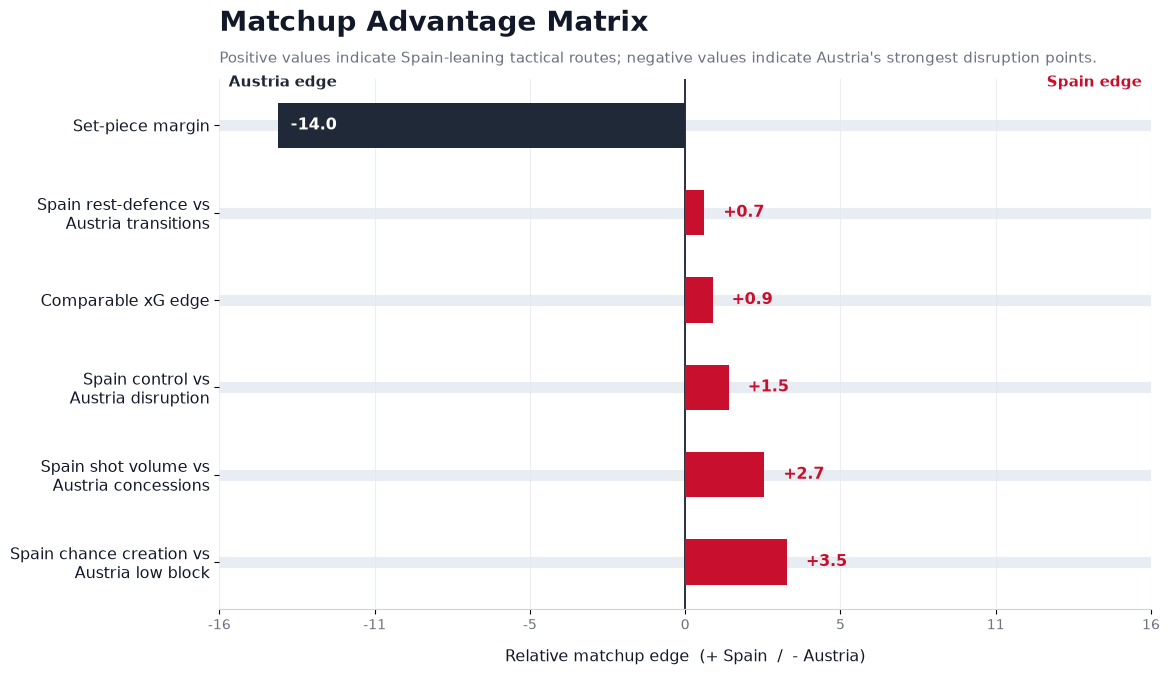

Saved: outputs\07_matchup_advantage_heatmap.png


In [29]:
# Matchup advantage matrix
# Positive values = Spain-leaning route
# Negative values = Austria-leaning route

matchups = pd.DataFrame([
    ["Spain control vs\nAustria disruption", style_indexes.loc["Spain", "control_index"] - style_indexes.loc["Austria", "disruption_index"]],
    ["Spain chance creation vs\nAustria low block", style_indexes.loc["Spain", "chance_creation_index"] - style_indexes.loc["Austria", "low_block_index"]],
    ["Spain rest-defence vs\nAustria transitions", style_indexes.loc["Spain", "rest_defence_index"] - style_indexes.loc["Austria", "transition_index"]],
    ["Spain shot volume vs\nAustria concessions", spain_comp["comp_shots_for"] - austria_comp["comp_shots_against"]],
    ["Set-piece margin", spain_style["set_piece_threat"] - austria_style["set_piece_threat"]],
    ["Comparable xG edge", spain_comp["comp_xg_for"] - austria_comp["comp_xg_for"]],
], columns=["matchup", "spain_edge"])

matchups["abs_edge"] = matchups["spain_edge"].abs()
matchups = matchups.sort_values("spain_edge").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11.8, 6.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

y = np.arange(len(matchups))
max_abs = max(5, float(np.ceil(matchups["abs_edge"].max() + 2)))

# Background guide line for each row
for yi in y:
    ax.plot(
        [-max_abs, max_abs],
        [yi, yi],
        color="#E8EDF3",
        lw=8,
        solid_capstyle="round",
        zorder=0
    )

# Central neutral line
ax.axvline(0, color=TEXT, lw=1.25, zorder=1)

# Bars + value labels
for i, row in matchups.iterrows():
    value = row["spain_edge"]
    color = SPAIN if value >= 0 else AUSTRIA

    ax.barh(
        i,
        abs(value),
        left=min(0, value),
        height=0.52,
        color=color,
        edgecolor="none",
        zorder=3
    )

    # Value label placement
    if abs(value) >= max_abs * 0.22:
        ax.text(
            value - 0.45 if value > 0 else value + 0.45,
            i,
            f"{value:+.1f}",
            ha="right" if value > 0 else "left",
            va="center",
            fontsize=11.2,
            fontweight="bold",
            color="white"
        )
    else:
        ax.text(
            value + 0.65 if value > 0 else value - 0.65,
            i,
            f"{value:+.1f}",
            ha="left" if value > 0 else "right",
            va="center",
            fontsize=11.2,
            fontweight="bold",
            color=color
        )

# Y labels
ax.set_yticks(y)
ax.set_yticklabels(matchups["matchup"], fontsize=11.2, color=TEXT)
ax.invert_yaxis()

# Title and subtitle
ax.text(
    0.0, 1.09,
    "Matchup Advantage Matrix",
    transform=ax.transAxes,
    fontsize=20,
    fontweight="bold",
    color=TEXT,
    ha="left"
)

ax.text(
    0.0, 1.03,
    "Positive values indicate Spain-leaning tactical routes; negative values indicate Austria's strongest disruption points.",
    transform=ax.transAxes,
    fontsize=10.8,
    color=GREY,
    ha="left"
)

# Side headers
ax.text(
    0.01, 0.985,
    "Austria edge",
    transform=ax.transAxes,
    fontsize=10.5,
    fontweight="bold",
    color=AUSTRIA,
    ha="left"
)

ax.text(
    0.99, 0.985,
    "Spain edge",
    transform=ax.transAxes,
    fontsize=10.5,
    fontweight="bold",
    color=SPAIN,
    ha="right"
)

# Axes styling
ax.set_xlim(-max_abs, max_abs)
xticks = np.linspace(-max_abs, max_abs, 7)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{x:.0f}" for x in xticks], fontsize=10.2, color=GREY)
ax.set_xlabel("Relative matchup edge  (+ Spain  /  - Austria)", fontsize=11.2, color=TEXT, labelpad=12)

ax.grid(axis="x", color=GRID, linewidth=0.8, alpha=0.7)
ax.set_axisbelow(True)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#CBD5E1")

plt.tight_layout(rect=[0, 0, 1, 0.92])
save_chart("07_matchup_advantage_heatmap.png")

## 17. Analytical takeaways

In [40]:
# Create a concise interpretation table from model outputs
takeaways = pd.DataFrame([
    ["Main structural edge", "Spain", "The model favours Spain through possession control, xG generation and comparable performances against compact opponents."],
    ["Main Austria route", "Austria", "Austria's route is not sustained control; it is pressure disruption, transition moments and set-piece threat."],
    ["Key uncertainty", "Both", "Spain's chance volume does not always translate into goals, and Austria's volatile group-stage profile increases scenario uncertainty."],
    ["Model watchpoint", "Spain", "If Spain turn territorial control into box entries early, the simulation shifts strongly toward Spain."],
    ["Model watchpoint", "Austria", "If Austria keep the match level deep into the second half, transition and set-piece scenarios become much more valuable."]
], columns=["theme", "team_edge", "interpretation"])

display(takeaways)

,theme,team_edge,interpretation
0,Main structural edge,Spain,The model favours Spain through possession con...
1,Main Austria route,Austria,Austria's route is not sustained control; it i...
2,Key uncertainty,Both,Spain's chance volume does not always translat...
3,Model watchpoint,Spain,If Spain turn territorial control into box ent...
4,Model watchpoint,Austria,If Austria keep the match level deep into the ...


## 18. Post-match validation template

The project should be judged after the game. This template records what the model expected and what actually happened.

In [19]:
# Save a post-match validation template
validation = projected_stats[["metric", "spain_low", "spain_high", "austria_low", "austria_high", "basis"]].copy()
validation["actual_spain"] = np.nan
validation["actual_austria"] = np.nan
validation["spain_in_range"] = ""
validation["austria_in_range"] = ""
validation["comment"] = ""
validation_path = OUTPUT_DIR / "post_match_validation_template.csv"
validation.to_csv(validation_path, index=False)

print(f"Saved: {validation_path.relative_to(PROJECT_ROOT)}")
display(validation.round(2))

Saved: outputs\post_match_validation_template.csv


,metric,spain_low,spain_high,austria_low,austria_high,basis,actual_spain,actual_austria,spain_in_range,austria_in_range,comment
0,Possession (%),62.89,70.91,31.11,35.09,Comparable possession + style-control adjustment,NaN,NaN,,,
1,xG,1.46,2.28,0.60,0.93,Final style-adjusted xG from our model,NaN,NaN,,,
2,Goals,1.03,2.71,0.42,1.11,Monte Carlo goal distribution mean,NaN,NaN,,,
3,Shots,13.17,19.75,5.21,7.82,xG divided by modelled shot quality,NaN,NaN,,,
4,Shots on target,3.77,6.28,1.87,3.12,Shots multiplied by observed SOT-rate profile,NaN,NaN,,,
5,Corners,5.42,8.48,1.79,2.80,Shot volume + territorial pressure,NaN,NaN,,,
6,Passes,590.07,721.19,274.06,334.96,Possession model converted into pass-volume ex...,NaN,NaN,,,
7,High recoveries,5.77,9.42,6.73,10.98,Observed recoveries + pressing/disruption style,NaN,NaN,,,
8,Fouls,11.58,16.66,15.69,22.57,Observed fouls + game-disruption style,NaN,NaN,,,


## 19. Output files

In [20]:
# List generated outputs
for path in sorted(OUTPUT_DIR.glob("*")):
    print(path.relative_to(PROJECT_ROOT))

outputs\01_style_adjusted_xg_decomposition.png
outputs\02_monte_carlo_outcome_probabilities.png
outputs\03_scoreline_probability_matrix.png
outputs\04_projected_match_stats_forecast_card.png
outputs\05_tactical_style_radar.png
outputs\06_composite_tactical_indexes.png
outputs\07_matchup_advantage_heatmap.png
outputs\08_tactical_preview_map.png
outputs\model_derived_projected_stats.csv
outputs\post_match_validation_template.csv
